# OneLand — 4 workers + cash

Set-packing over `crop_rollouts.json` + `animal_rollouts.json` (Coupled-Open style).

- **25 tiles** — one NW 5×5 land
- **4 workers** — farmer + 3 daily hires (fib cost 1+1+2 = $4/day)
- **Open** wheat/fertilizer — buy shortfall at I0 ($25 / $100)
- **Cash** — $3000 starting bank, never negative



In [1]:
import json

import collections
from ortools.sat.python import cp_model


In [2]:
import resource
import tracemalloc
from functools import wraps

def peak_mem(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        rss_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        tracemalloc.start()
        try:
            return fn(*args, **kwargs)
        finally:
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            rss_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            print(
                f"{fn.__name__}: "
                f"tracemalloc peak={peak / 1e6:.1f} MB, "
                f"RSS max={rss_after / 1024:.1f} MB "
                f"(was {rss_before / 1024:.1f} MB)"
            )
    return wrapper


In [3]:
with open("../data/crop_rollouts.json", "r") as f:
    crops_data = json.load(f)
with open("../data/animal_rollouts.json", "r") as f:
    animals_data = json.load(f)


In [4]:
NUM_DAYS = 30
NUM_TILES = 25
SETUP_OP_OVERHEAD = 1
WHEAT_PRICE = 25
FERT_PRICE = 100
MAX_BUY = NUM_TILES * NUM_DAYS
STARTING_MONEY = 3000
HIRE_DAILY_COST = 1 + 1 + 2  # always hire 3 hands (fib)

WORKERS = ("farmer", "hire1", "hire2", "hire3")
WORKER_TILES = {
    "farmer": list(range(0, 9)),
    "hire1": list(range(9, 15)),
    "hire2": list(range(15, 21)),
    "hire3": list(range(21, 25)),
}
NET_TILE_OPS = {"farmer": 15, "hire1": 15, "hire2": 15, "hire3": 14}

TILE_WORKER = (
    ["farmer"] * len(WORKER_TILES["farmer"])
    + ["hire1"] * len(WORKER_TILES["hire1"])
    + ["hire2"] * len(WORKER_TILES["hire2"])
    + ["hire3"] * len(WORKER_TILES["hire3"])
)


def worker_for_tile(tile: int) -> str:
    return TILE_WORKER[tile]


CROP_PROFILES = ("no_fert", "with_fert")
ANIMAL_PROFILES = ("no_care", "with_care")

elements = [(tile, day) for tile in range(NUM_TILES) for day in range(NUM_DAYS)]


def parse_age_maps(profile, label, kind):
    harvest_map = dict(zip(profile["harvest_ages"], profile["yield_per_harvest"]))
    ops_by_age = {}
    feed_by_age = {}
    fert_use_by_age = {}
    collect_by_age = {}
    wheat_gain_by_age = {}
    for day in profile["days"]:
        age = day["age"]
        acts = day["actions"]
        ops_by_age[age] = len(acts)
        feed_by_age[age] = 1 if "FEED" in acts else 0
        fert_use_by_age[age] = 1 if "FERTILIZE" in acts else 0
        collect_by_age[age] = 1 if "COLLECT_FERTILIZER" in acts else 0
        if kind == "crop" and label == "WHEAT" and age in harvest_map:
            wheat_gain_by_age[age] = harvest_map[age]
        else:
            wheat_gain_by_age[age] = 0
    return ops_by_age, feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age


def fill_daily_arrays(subset, ops_by_age, feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age):
    d_ops = [0] * NUM_DAYS
    d_feed = [0] * NUM_DAYS
    d_fert = [0] * NUM_DAYS
    d_collect = [0] * NUM_DAYS
    d_wheat = [0] * NUM_DAYS
    tile = subset["tile"]
    start = subset["start_day"]
    kind = subset["kind"]
    for d in range(NUM_DAYS):
        if (tile, d) not in subset["subset"]:
            continue
        age = d - start
        if age not in ops_by_age:
            continue
        n_ops = ops_by_age[age]
        if kind == "animal" and age == 0:
            n_ops += SETUP_OP_OVERHEAD
        d_ops[d] = n_ops
        d_feed[d] = feed_by_age.get(age, 0)
        d_fert[d] = fert_use_by_age.get(age, 0)
        d_collect[d] = collect_by_age.get(age, 0)
        d_wheat[d] = wheat_gain_by_age.get(age, 0)
    subset["daily_ops"] = d_ops
    subset["daily_feed"] = d_feed
    subset["daily_fert"] = d_fert
    subset["daily_collect"] = d_collect
    subset["daily_wheat"] = d_wheat


def build_cash_by_day(start_day, setup_cost, base_price, profile):
    cash = [0] * NUM_DAYS
    cash[start_day] -= setup_cost
    for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"]):
        hday = start_day + age
        if hday < NUM_DAYS:
            cash[hday] += yld * base_price
    return cash


subsets = []

for crop_name, crop_spec in crops_data["crops"].items():
    seed_cost = crop_spec["seed_cost"]
    base_price = crop_spec["base_price"]
    for profile_name in CROP_PROFILES:
        if profile_name not in crop_spec:
            continue
        profile = crop_spec[profile_name]
        age_maps = parse_age_maps(profile, crop_name, "crop")

        for tile, start_day in elements:
            subset = {
                "id": f"S{len(subsets)}",
                "kind": "crop",
                "label": crop_name,
                "profile": profile_name,
                "tile": tile,
                "worker": worker_for_tile(tile),
                "start_day": start_day,
                "subset": set(),
                "weight": 0,
            }
            fits = True
            for day in profile["days"]:
                cal = start_day + day["age"]
                if cal < NUM_DAYS:
                    subset["subset"].add((tile, cal))
                else:
                    fits = False
                    break
            if not fits:
                continue
            rev = sum(
                yld * base_price
                for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"])
                if start_day + age < NUM_DAYS
            )
            subset["weight"] = rev - seed_cost
            subset["cash_by_day"] = build_cash_by_day(start_day, seed_cost, base_price, profile)
            (
                subset["ops_by_age"],
                subset["feed_by_age"],
                subset["fert_use_by_age"],
                subset["collect_by_age"],
                subset["wheat_gain_by_age"],
            ) = age_maps
            fill_daily_arrays(subset, *age_maps)
            subsets.append(subset)

for animal_name, animal_spec in animals_data["animals"].items():
    animal_cost = animal_spec["animal_cost"]
    base_price = animal_spec["base_price"]
    for profile_name in ANIMAL_PROFILES:
        profile = animal_spec[profile_name]
        age_maps = parse_age_maps(profile, animal_name, "animal")

        for tile, start_day in elements:
            subset = {
                "id": f"S{len(subsets)}",
                "kind": "animal",
                "label": animal_name,
                "profile": profile_name,
                "tile": tile,
                "worker": worker_for_tile(tile),
                "start_day": start_day,
                "subset": set(),
                "weight": 0,
            }
            for age_day in profile["days"]:
                cal = start_day + age_day["age"]
                if cal < NUM_DAYS:
                    subset["subset"].add((tile, cal))
                else:
                    break
            if not subset["subset"]:
                continue
            rev = sum(
                yld * base_price
                for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"])
                if start_day + age < NUM_DAYS
            )
            subset["weight"] = rev - animal_cost
            subset["cash_by_day"] = build_cash_by_day(start_day, animal_cost, base_price, profile)
            (
                subset["ops_by_age"],
                subset["feed_by_age"],
                subset["fert_use_by_age"],
                subset["collect_by_age"],
                subset["wheat_gain_by_age"],
            ) = age_maps
            fill_daily_arrays(subset, *age_maps)
            subsets.append(subset)

print(f"{len(subsets)} candidates")


9300 candidates


In [5]:
# Declare the model
model = cp_model.CpModel()


In [6]:
# One binary decision var per candidate subset
y = {s["id"]: model.NewBoolVar(s["id"]) for s in subsets}


In [7]:
# Packing constraint: each (tile, day) covered by at most one selected subset
element_to_vars = {}
for s in subsets:
    var = y[s["id"]]
    for e in s["subset"]:
        element_to_vars.setdefault(e, []).append(var)

for e in elements:
    covering = element_to_vars.get(e)
    if covering:
        model.Add(sum(covering) <= 1)


In [8]:
# Per-worker daily ops cap (NET_TILE_OPS after one zone traversal)
worker_day_terms = {}
for s in subsets:
    var = y[s["id"]]
    w = s["worker"]
    for day in range(NUM_DAYS):
        ops = s["daily_ops"][day]
        if ops:
            worker_day_terms.setdefault((w, day), []).append(var * ops)

for worker in WORKERS:
    cap = NET_TILE_OPS[worker]
    for day in range(NUM_DAYS):
        operations = worker_day_terms.get((worker, day))
        if operations:
            model.Add(sum(operations) <= cap)


In [9]:
# Open wheat / fertilizer: buy shortfall at fixed I0 prices
buy_w = []
buy_f = []
buy_w_cost = []
buy_f_cost = []

cum_wheat_supply = 0
cum_wheat_demand = 0
cum_fert_supply = 0
cum_fert_demand = 0

for d in range(NUM_DAYS):
    feed_d = sum(y[s["id"]] * s["daily_feed"][d] for s in subsets)
    fert_d = sum(y[s["id"]] * s["daily_fert"][d] for s in subsets)
    collect_d = sum(y[s["id"]] * s["daily_collect"][d] for s in subsets)
    wheat_d = sum(y[s["id"]] * s["daily_wheat"][d] for s in subsets)

    bw = model.NewIntVar(0, MAX_BUY, f"buy_w_{d}")
    bf = model.NewIntVar(0, MAX_BUY, f"buy_f_{d}")
    model.Add(bw >= feed_d - cum_wheat_supply + cum_wheat_demand)
    model.Add(bf >= fert_d - cum_fert_supply + cum_fert_demand)
    buy_w.append(bw)
    buy_f.append(bf)
    buy_w_cost.append(WHEAT_PRICE * bw)
    buy_f_cost.append(FERT_PRICE * bf)

    cum_wheat_supply += wheat_d
    cum_wheat_demand += feed_d
    cum_fert_supply += collect_d
    cum_fert_demand += fert_d


In [10]:
# Cash-on-hand: starting bank + cumulative flows never negative
cum_terms = []
for d in range(NUM_DAYS):
    for s in subsets:
        cash = s["cash_by_day"][d]
        if cash:
            cum_terms.append(y[s["id"]] * cash)
    cum_terms.append(-WHEAT_PRICE * buy_w[d])
    cum_terms.append(-FERT_PRICE * buy_f[d])
    cum_terms.append(-HIRE_DAILY_COST)
    model.Add(STARTING_MONEY + sum(cum_terms) >= 0)


In [11]:
# Objective: harvest revenue minus setup costs minus market wheat/fert purchases
model.Maximize(
    sum(s["weight"] * y[s["id"]] for s in subsets)
    - sum(buy_w_cost)
    - sum(buy_f_cost)
)


In [12]:
@peak_mem
def run(_solver):
    return _solver.Solve(model)

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 120
solver.parameters.num_workers = 8
status = run(solver)

print(status, solver.StatusName(status))
print("objective:", solver.ObjectiveValue())
hire_total = HIRE_DAILY_COST * NUM_DAYS
print(f"implied bank delta (obj - hires): {solver.ObjectiveValue() - hire_total:.0f}")
print(f"implied ending bank: {STARTING_MONEY + solver.ObjectiveValue() - hire_total:.0f}")


run: tracemalloc peak=0.0 MB, RSS max=1484.0 MB (was 299.4 MB)
CpSolverStatus.FEASIBLE FEASIBLE
objective: 90105.0
implied bank delta (obj - hires): 89985
implied ending bank: 92985


In [13]:
selected = [s for s in subsets if solver.Value(y[s["id"]]) == 1]
print("n selected:", len(selected))
for s in selected:
    tag = f"{s['kind'][0]}{s['profile'][0]}{s['start_day']}"
    print(
        f"  {tag} {s['label']:10} {s['profile']:9} "
        f"tile={s['tile']:2d} {s['worker']:6s} start={s['start_day']:2d} weight={s['weight']:.0f}"
    )

worker_daily_ops = {w: [0] * NUM_DAYS for w in WORKERS}
for s in selected:
    w = s["worker"]
    for d in range(NUM_DAYS):
        worker_daily_ops[w][d] += s["daily_ops"][d]

print("\npeak ops/day by worker:")
for w in WORKERS:
    peak = max(worker_daily_ops[w])
    peak_day = worker_daily_ops[w].index(peak)
    print(f"  {w:6s} peak={peak:2d}/{NET_TILE_OPS[w]} on day {peak_day}")

balance = STARTING_MONEY
min_bal = balance
for d in range(NUM_DAYS):
    flow = sum(s["cash_by_day"][d] for s in selected)
    flow -= solver.Value(buy_w[d]) * WHEAT_PRICE
    flow -= solver.Value(buy_f[d]) * FERT_PRICE
    flow -= HIRE_DAILY_COST
    balance += flow
    min_bal = min(min_bal, balance)
print(f"\ncash floor (selected replay): {min_bal:.0f}")

trace_days = min(16, NUM_DAYS)
print(f"\nInventory trace (recomputed, d=0..{trace_days - 1}):")
print("  d    W[d]  F[d]  buy_w  buy_f")
wheat_level, fert_level = 0, 0
for d in range(trace_days):
    bw = solver.Value(buy_w[d])
    bf = solver.Value(buy_f[d])
    print(f"  {d:2d}  {wheat_level:5d}  {fert_level:5d}  {bw:5d}  {bf:5d}")
    feed_d = sum(s["daily_feed"][d] for s in selected)
    fert_d = sum(s["daily_fert"][d] for s in selected)
    collect_d = sum(s["daily_collect"][d] for s in selected)
    wheat_d = sum(s["daily_wheat"][d] for s in selected)
    wheat_level += wheat_d + bw - feed_d
    fert_level += collect_d + bf - fert_d

total_wheat_buy = sum(solver.Value(bw) for bw in buy_w)
total_fert_buy = sum(solver.Value(bf) for bf in buy_f)
print(f"\nTotal wheat buy: {total_wheat_buy} units ({total_wheat_buy * WHEAT_PRICE:.0f} coins)")
print(f"Total fert buy:  {total_fert_buy} units ({total_fert_buy * FERT_PRICE:.0f} coins)")


n selected: 78
  cn0 WHEAT      no_fert   tile=23 hire3  start= 0 weight=90
  cn0 WHEAT      no_fert   tile=24 hire3  start= 0 weight=90
  cw2 WHEAT      with_fert tile= 1 farmer start= 2 weight=140
  cw4 WHEAT      with_fert tile= 2 farmer start= 4 weight=140
  cw9 WHEAT      with_fert tile= 2 farmer start= 9 weight=140
  cw14 WHEAT      with_fert tile= 2 farmer start=14 weight=140
  cw11 WHEAT      with_fert tile= 3 farmer start=11 weight=140
  cw16 WHEAT      with_fert tile= 3 farmer start=16 weight=140
  cw21 WHEAT      with_fert tile= 3 farmer start=21 weight=140
  cw2 WHEAT      with_fert tile= 4 farmer start= 2 weight=140
  cw12 WHEAT      with_fert tile= 5 farmer start=12 weight=140
  cw12 WHEAT      with_fert tile= 6 farmer start=12 weight=140
  cw4 WHEAT      with_fert tile= 7 farmer start= 4 weight=140
  cw9 WHEAT      with_fert tile= 7 farmer start= 9 weight=140
  cw14 WHEAT      with_fert tile= 7 farmer start=14 weight=140
  cw11 WHEAT      with_fert tile= 8 farmer start=1

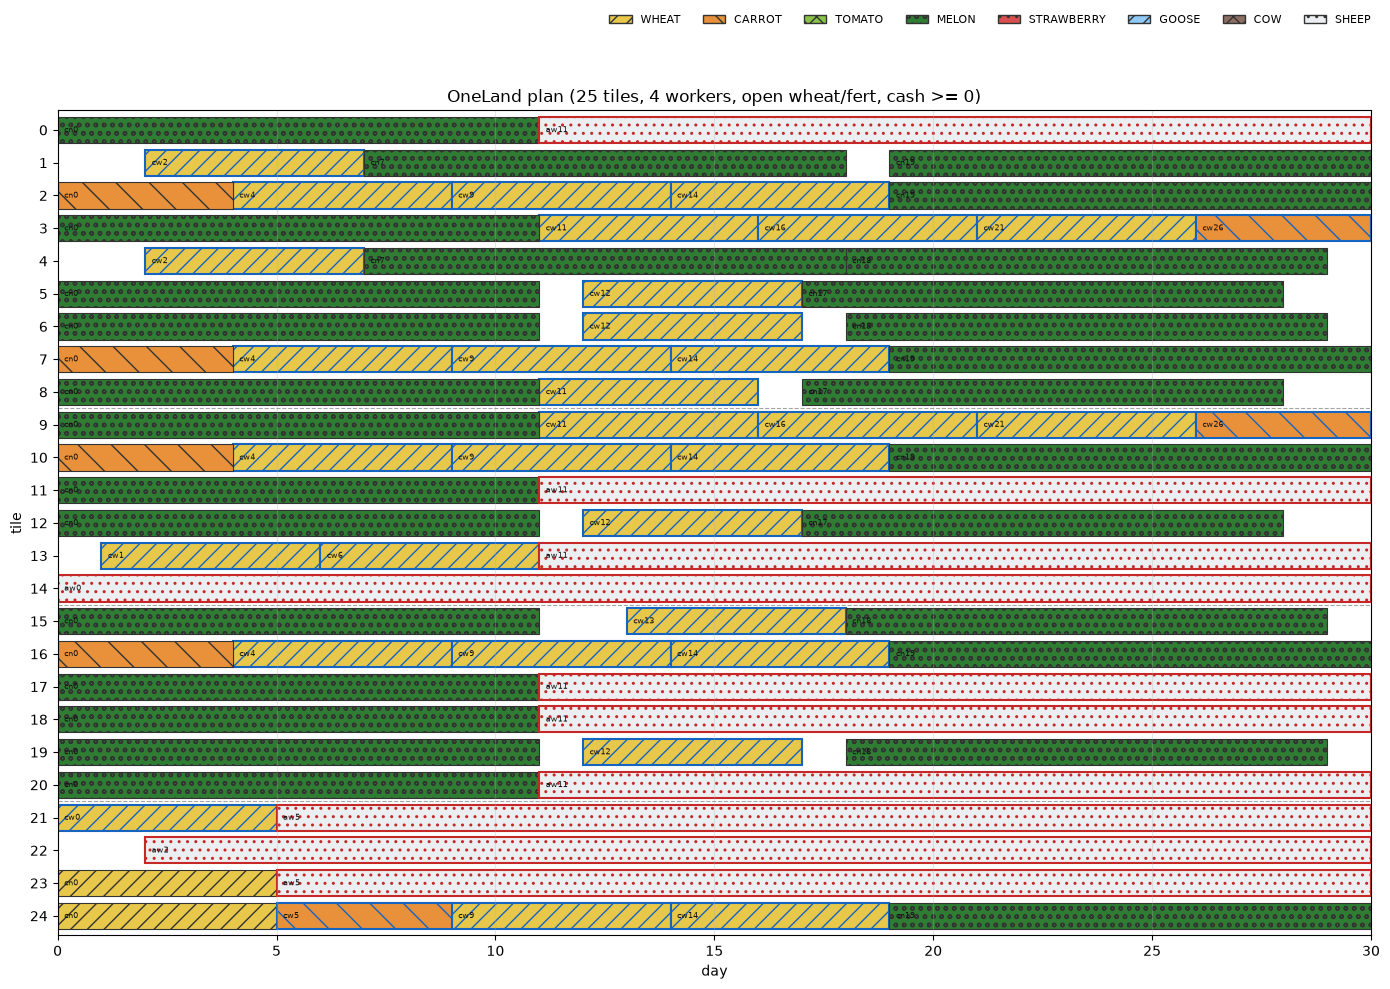

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CROP_STYLE = {
    "WHEAT": {"color": "#e8c84a", "hatch": "//"},
    "CARROT": {"color": "#e8913a", "hatch": "\\"},
    "TOMATO": {"color": "#8bc34a", "hatch": "xx"},
    "MELON": {"color": "#2e7d32", "hatch": "oo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": ".."},
}
ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "//"},
    "COW": {"color": "#8d6e63", "hatch": "xx"},
    "SHEEP": {"color": "#eceff1", "hatch": ".."},
}


def bar_style(s):
    if s["kind"] == "crop":
        st = dict(CROP_STYLE.get(s["label"], {"color": "#999999", "hatch": ""}))
    else:
        st = dict(ANIMAL_STYLE.get(s["label"], {"color": "#999999", "hatch": ""}))
    if s["profile"] in ("with_fert", "with_care"):
        st["edgecolor"] = "#1565c0" if s["kind"] == "crop" else "#c62828"
        st["linewidth"] = 1.5
    else:
        st.setdefault("edgecolor", "#333333")
        st.setdefault("linewidth", 0.8)
    return st


fig, ax = plt.subplots(figsize=(14, 10))
for s in selected:
    days = sorted(d for _, d in s["subset"])
    start, end = days[0], days[-1] + 1
    st = bar_style(s)
    ax.barh(
        y=s["tile"],
        width=end - start,
        left=start,
        height=0.8,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor=st["edgecolor"],
        linewidth=st["linewidth"],
    )
    tag = f"{s['kind'][0]}{s['profile'][0]}{s['start_day']}"
    ax.text(start + 0.15, s["tile"], tag, va="center", fontsize=6, color="#111")

for yline in (8.5, 14.5, 20.5):
    ax.axhline(yline, color="#666666", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_xlabel("day")
ax.set_ylabel("tile")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, NUM_DAYS)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title("OneLand plan (25 tiles, 4 workers, open wheat/fert, cash >= 0)")
ax.invert_yaxis()
legend_handles = [
    Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
    for name, st in {**CROP_STYLE, **ANIMAL_STYLE}.items()
]
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    bbox_transform=fig.transFigure,
    ncol=len(legend_handles),
    fontsize=8,
    frameon=False,
)
# out_path = "oneland_gantt.png"
# fig.savefig(out_path, dpi=120, bbox_inches="tight")
# plt.close(fig)
# print(f"saved {out_path}")
plt.show()
